# Sales Territory Analysis Project

# This project analyzes sales performance across selected sales territories 

# Region: Northeast

# Territories  Being Analyzed 
  - New Jersey
  - Maryland
    

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
sales = pd.read_csv("StoreSales.csv")

sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [23]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [24]:
stores = pd.read_csv("StoreDetail.csv")

stores.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [25]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [26]:
customers = pd.read_csv(
    "customer_list.csv",
    sep='|'
)

customers.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [27]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


In [28]:
products = pd.read_csv("Products.csv")

products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [29]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [30]:
categories = pd.read_csv(
    "ProductCategories.csv"
)

categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [31]:
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


# Core Marketing Analysis

## Territory Managers and Store Locations

## Territory Managers and Store Locations

This analysis identifies:
- The territory managers for Maryland and New Jersey
- The stores assigned to each territory
- Store locations for each territory

In [34]:
# Merge sales and store data
merged_df = sales.merge(
    stores,
    on='Store ID',
    how='left'
)

# Keep only Maryland and New Jersey
territory_sales = merged_df.loc[
    merged_df['State'].isin([
        'Maryland',
        'New Jersey'
    ])
].copy()

# Show territory manager information
territory_info = territory_sales[
    [
        'Territory Manager',
        'Store ID',
        'Store Location',
        'State'
    ]
].drop_duplicates()

territory_info

,Territory Manager,Store ID,Store Location,State
32,Shruti Reddy,731,Annapolis,Maryland
33,Shruti Reddy,733,Baltimore,Maryland
34,Shruti Reddy,734,Germantown,Maryland
35,Shruti Reddy,735,Howard,Maryland
36,Shruti Reddy,736,North Harford,Maryland
77,Shruti Reddy,737,Parkville,Maryland
78,Shruti Reddy,738,Queen Anne's County,Maryland
101,Miami Vue,824,Atlantic City,New Jersey
102,Miami Vue,826,Cape May,New Jersey
104,Miami Vue,827,Clifton,New Jersey


The output above shows the territory managers and the stores assigned to each territory.

## Monthly Total Revenue for In-Store Sales

Analysis will calculates monthly total revenue for Maryland and New Jersey territories

In [35]:
# Convert date column
territory_sales['Transaction Date'] = pd.to_datetime(
    territory_sales['Transaction Date']
)

# Create Month column
territory_sales['Month'] = (
    territory_sales['Transaction Date']
    .dt.to_period('M')
)

# Monthly revenue
monthly_revenue = (
    territory_sales
    .groupby(['Month', 'State'])['Sale Amount']
    .sum()
    .reset_index()
)

monthly_revenue.head()

,Month,State,Sale Amount
0,2022-01,Maryland,190064.90
1,2022-01,New Jersey,70597.51
2,2022-02,Maryland,197529.18
3,2022-02,New Jersey,63225.69
4,2022-03,Maryland,210228.48


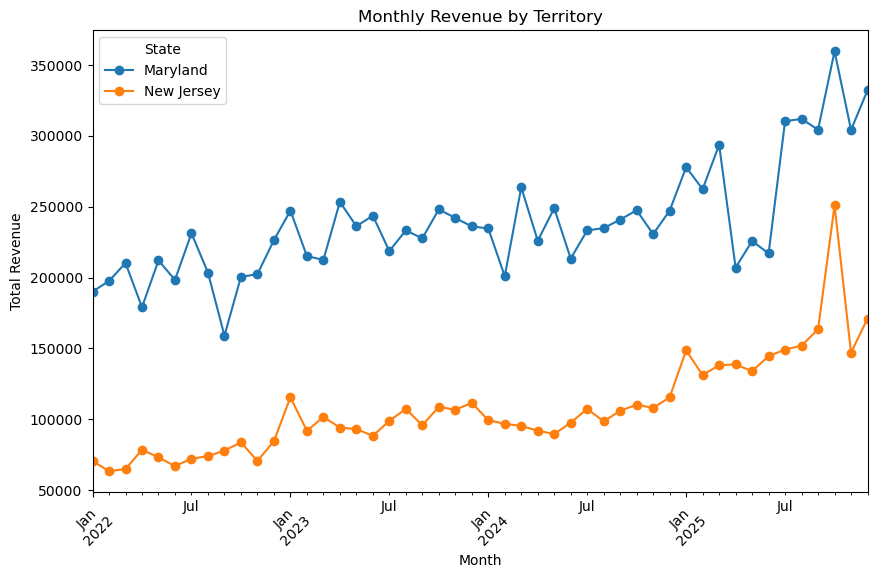

In [36]:
import matplotlib.pyplot as plt

# Create pivot table
pivot_revenue = monthly_revenue.pivot(
    index='Month',
    columns='State',
    values='Sale Amount'
)

# Create line chart
pivot_revenue.plot(
    figsize=(10,6),
    marker='o'
)

plt.title(
    'Monthly Revenue by Territory'
)

plt.xlabel('Month')

plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.show()

The chart compares revenue trends between Maryland and New Jersey and helps identify stronger-performing territories.

## Store Performance Ranking

This ranks stores by total sales revenue to identify the top performing stores in the territory

In [37]:
# Store performance ranking
store_ranking = (
    territory_sales
    .groupby(
        ['State', 'Store ID']
    )['Sale Amount']
    .sum()
    .reset_index()
    .sort_values(
        by='Sale Amount',
        ascending=False
    )
)

store_ranking.head(10)

,State,Store ID,Sale Amount
5,Maryland,736,8708119.00
20,New Jersey,835,623163.53
23,New Jersey,838,597565.68
3,Maryland,734,584675.92
6,Maryland,737,320441.24
4,Maryland,735,319394.58
8,Maryland,739,318511.04
15,New Jersey,830,316775.48
9,New Jersey,824,314513.77
19,New Jersey,834,311056.42


## Top Customers

In this section we identify the top customers based on our total sales revenue

In [46]:
# Merge customer and sales data
customer_sales = territory_sales.merge(
    customers,
    left_on='RewardsID',
    right_on='cust_id',
    how='left'
)

# Find top customers
top_customers = (
    customer_sales
    .groupby(
        ['cust_id', 'name']
    )['Sale Amount']
    .sum()
    .reset_index()
    .sort_values(
        by='Sale Amount',
        ascending=False
    )
)

# Show top 10 customers
top_customers.head(10)

,cust_id,name,Sale Amount
179,180.0,Cole Brown,10527.20
74,75.0,Magnitude,8127.92
249,250.0,Michael,7969.17
160,161.0,Lieutenant Duffy,7821.58
354,355.0,Donna Hayward,7488.15
30,31.0,Homer S.,7302.37
98,99.0,Trent Lane,7239.63
146,147.0,Arthur Fonzarelli,6981.15
418,419.0,Count von Count,6824.08
144,145.0,Adam Newman,6817.71


## Product Category Analysis

Analyzing the number of transactions and total revenue by the product category for every month in the Maryland and New Jersey

In [54]:
product_data = products.merge(
    categories,
    on='CategoryID',
    how='left'
)

sales_products = territory_sales.merge(
    product_data,
    on='Prod Num',
    how='left'
)


sales_products.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Month,Product,CategoryID,SubcategoryID_x,Category,SubcategoryID_y,Subcategory
0,2022-01-01,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Silver Brush Limited Ruby Satin Brushes (Set o...,115,115-pai,Art Supplies,115-ske,Sketchbooks and Paper
1,2022-01-01,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Silver Brush Limited Ruby Satin Brushes (Set o...,115,115-pai,Art Supplies,115-kid,Kids Art Supplies
2,2022-01-01,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Silver Brush Limited Ruby Satin Brushes (Set o...,115,115-pai,Art Supplies,115-mis,Miscellaneous Art Supplies
3,2022-01-01,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Silver Brush Limited Ruby Satin Brushes (Set o...,115,115-pai,Art Supplies,115-pai,Paint Brushes
4,2022-01-01,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Silver Brush Limited Ruby Satin Brushes (Set o...,115,115-pai,Art Supplies,115-scu,Sculpting Supplies


In [56]:
transactions_by_category = (
    sales_products
    .groupby(
        ['Month', 'Category']
    )['Prod Num']
    .count()
    .reset_index(name='Transaction Count')
)

transactions_by_category.head()   

,Month,Category,Transaction Count
0,2022-01,Apparel and Merchandise,2712
1,2022-01,Art Supplies,3685
2,2022-01,Books (General),1340
3,2022-01,Stationery and Supplies,3817
4,2022-01,Technology & Accessories,2779


In [57]:
revenue_by_category = (
    sales_products
    .groupby(
         ['Month', 'Category']
    )['Sale Amount']
    .sum()
    .reset_index()
)

revenue_by_category.head()

,Month,Category,Sale Amount
0,2022-01,Apparel and Merchandise,88446.16
1,2022-01,Art Supplies,115006.21
2,2022-01,Books (General),48001.04
3,2022-01,Stationery and Supplies,40043.74
4,2022-01,Technology & Accessories,1161606.60


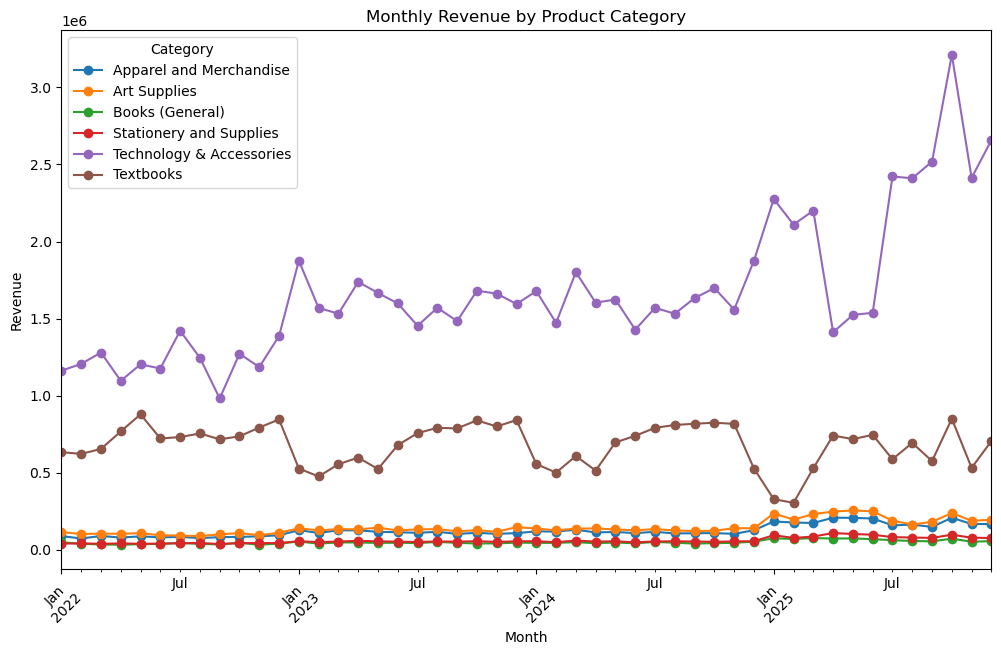

In [58]:
pivot_category = revenue_by_category.pivot(
    index='Month',
    columns='Category',
    values='Sale Amount'
)

pivot_category.plot(
    figsize=(12,7),
    marker='o'
)

plt.title(
    'Monthly Revenue by Product Category'
)

plt.xlabel('Month')

plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

### Product Catergory Findings

In the analysis shows which products categories generated the highest number of transactions and revenue.
Higher transaction counts may indicate more popular products and the lower performing categories could show opportunites for the future marketing campaigns

FINAL RECOMMENDATION

# Final Recommendation

Based on the analysis completed:

- Maryland and New Jersey showed different revenue trends over time.
- Certain stores consistently outperformed others in total revenue.
- Some product categories generated significantly higher revenue and transaction counts.
- Top customers contributed a large portion of total sales revenue.

## Recommendation

Marketing efforts next quarter should focus on:

1. Increasing advertising and promotions in the strongest-performing territory.
2. Supporting weaker stores with local promotions and customer engagement campaigns.
3. Expanding marketing around the highest-performing product categories.
4. Creating loyalty programs targeting top customers.
5. Using successful stores as models for improving lower-performing locations.

Overall, the company should focus marketing investment on areas with strong sales momentum while improving underperforming stores through targeted promotional strategies